In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
import random

import tensorflow as tf

from functions.model import (
    Model
    ,train_step
    ,finalModel
    ,evaluateFinalModel
    ,evaluateSingleModel
)
from functions.prepare_data import prepare_data

# machine learning

In [74]:
data = pd.read_csv('bank_data_prediction_task.csv', index_col = 0)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\IPython\core\interactiveshell.py:3170: DtypeWarning: Columns (8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [66]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'test_control_flag'],
      dtype='object')

In [68]:
data.test_control_flag.unique()

array(['campaign group', 'control group'], dtype=object)

## use mix of categorical and continuous variables with one hot encoding

I think that for columns with binary values like 'default', 'housing', 'loan', 'contactedBefore' I don't need to use one hot encoding but for now I will use it because that is simpler

In [76]:
x_categorical_list, x_continuous_list, y_list = prepare_data(3)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [5]:
i = 0
print(x_categorical_list[i].shape)
print(x_continuous_list[i].shape)
print(y_list[i].shape)

(7148, 39)
(7148, 4)
(7148,)


In [6]:
# compare number of ones with number of zeros in y
i = 2
y = y_list[i]
len(y[y == 1]) / len(y[y == 0])

0.532590051457976

In [165]:
# # test if we can calculate gradients

# model = Model()

# with tf.GradientTape() as tape:
#     output = model(x_encoded, x_continuous)
    
# variables = model.trainable_variables
# gradients = tape.gradient(output, variables)

In [7]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

In [21]:
# # testing calculating loss

# model = Model(
#     categorical_no_neurons = [30], # list with number of neurons for each layer of categorical input
#     categorical_activations = ['relu'], # list with activation functions for each layer of categorical input
#     continuous_no_neurons = [100, 200, 100], # list with number of neurons for each layer of continuous input
#     continuous_activations = ['relu', 'relu', 'relu'], # list with activation functions for each layer of continuous input
#     output_shape = 2
# )
# pred = model(x_categorical_list[0], x_continuous_list[0])

# print(loss_object(y_list[0], pred))

tf.Tensor(0.6849109, shape=(), dtype=float32)


In [68]:
# # testing train_step

# batch_number = 0
# batch_size = 10

# x_categorical_batch = x_categorical[batch_number * batch_size : (batch_number + 1) * batch_size, :]
# x_continuous_batch = x_continuous[batch_number * batch_size : (batch_number + 1) * batch_size, :]
# y_batch = y[batch_number * batch_size : (batch_number + 1) * batch_size]

# model = Model(
#     categorical_no_neurons = [30], # list with number of neurons for each layer of categorical input
#     categorical_activations = ['relu'], # list with activation functions for each layer of categorical input
#     continuous_no_neurons = [100, 200, 100], # list with number of neurons for each layer of continuous input
#     continuous_activations = ['relu', 'relu', 'relu'], # list with activation functions for each layer of continuous input
#     output_shape = 2
# )

# train_step(
#     x_categorical_batch,
#     x_continuous_batch,
#     y_batch,
#     model,
#     loss_function, 
#     optimizer
# )

In [9]:
# Training the model

epochs = 10
batch_size = 40

# create different models for each dataset
models = [
    Model(
        categorical_no_neurons = [30], # list with number of neurons for each layer of categorical input
        categorical_activations = ['relu'], # list with activation functions for each layer of categorical input
        continuous_no_neurons = [100, 200, 100], # list with number of neurons for each layer of continuous input
        continuous_activations = ['relu', 'relu', 'relu'], # list with activation functions for each layer of continuous input
        output_shape = 2
    )
    for i in range(len(y_list))
]

for model, x_categorical, x_continuous, y in zip(
    models,
    x_categorical_list,
    x_continuous_list,
    y_list
):
    for epoch in range(epochs):
        stime = time()
        total_loss = 0
        for batch_number in range(len(y) // batch_size):
            x_categorical_batch = x_categorical[batch_number * batch_size : (batch_number + 1) * batch_size, :]
            x_continuous_batch = x_continuous[batch_number * batch_size : (batch_number + 1) * batch_size, :]
            y_batch = y[batch_number * batch_size : (batch_number + 1) * batch_size]
            y_batch = np.expand_dims(y_batch, 1)

            batch_loss = train_step(
                x_categorical_batch,
                x_continuous_batch,
                y_batch,
                model,
                loss_object, 
                optimizer
            )

            total_loss += batch_loss

            # print(f'Batch number: {batch_number}, Loss: {batch_loss / batch_size}, Time per batch: {(time() - stime) / (batch_number + 1)}')
            if batch_loss / batch_size < 0.001:
                break
                
        if batch_loss / batch_size < 0.001:
            break
        
#     print(f'Epoch: {epoch + 1}, Loss: {total_loss / ((batch_number + 1) * batch_size)}, Time per epoch: {time() - stime}\n')
    # break
    # if batch_loss / batch_size < 0.9:
    #     break

# Evaluate the model

In [13]:
# evaluating final model

x_categorical, x_continuous, y = prepare_data(1)
x_categorical = x_categorical[0]
x_continuous = x_continuous[0]
y = y[0]
threshold = 0.5

tp, tn, fp, fn = evaluateFinalModel(models, x_categorical, x_continuous, y, threshold)

# check precision
precision = tp / (tp + fp)

# check recall
recall = tp / (tp + fn)

print('recall: ', recall)
print('precision: ', precision)

# confusion matrix
print('confusion matrix: \n',
    np.array([
        [tp, fn], 
        [fp, tn]
    ])
)

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


recall:  0.5611916264090178
precision:  0.2336182336182336
confusion matrix: 
 [[1394 1090]
 [4573 9419]]


In [41]:
# evaluating a single model

i = 1
model = models[i]
x_categorical = x_categorical_list[i]
x_continuous = x_continuous_list[i]
y = y_list[i]
threshold = 0.5

tp, tn, fp, fn = evaluateSingleModel(model, x_categorical, x_continuous, y, threshold)

# check precision
try:
    precision = tp / (tp + fp)
except:
    precision = 'undefined'
    
# check recall
try:
    recall = tp / (tp + fn)
except:
    recall = 'undefined'

print('recall: ', recall)
print('precision: ', precision)

# confusion matrix
print('confusion matrix: \n',
    np.array([
        [tp, fn], 
        [fp, tn]
    ])
)

recall:  0.0
precision:  undefined
confusion matrix: 
 [[   0 2484]
 [   0 4664]]


In [19]:
# check accuracy
len(np.where(y == pred)[0]) / len(y)

NameError: name 'pred' is not defined

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


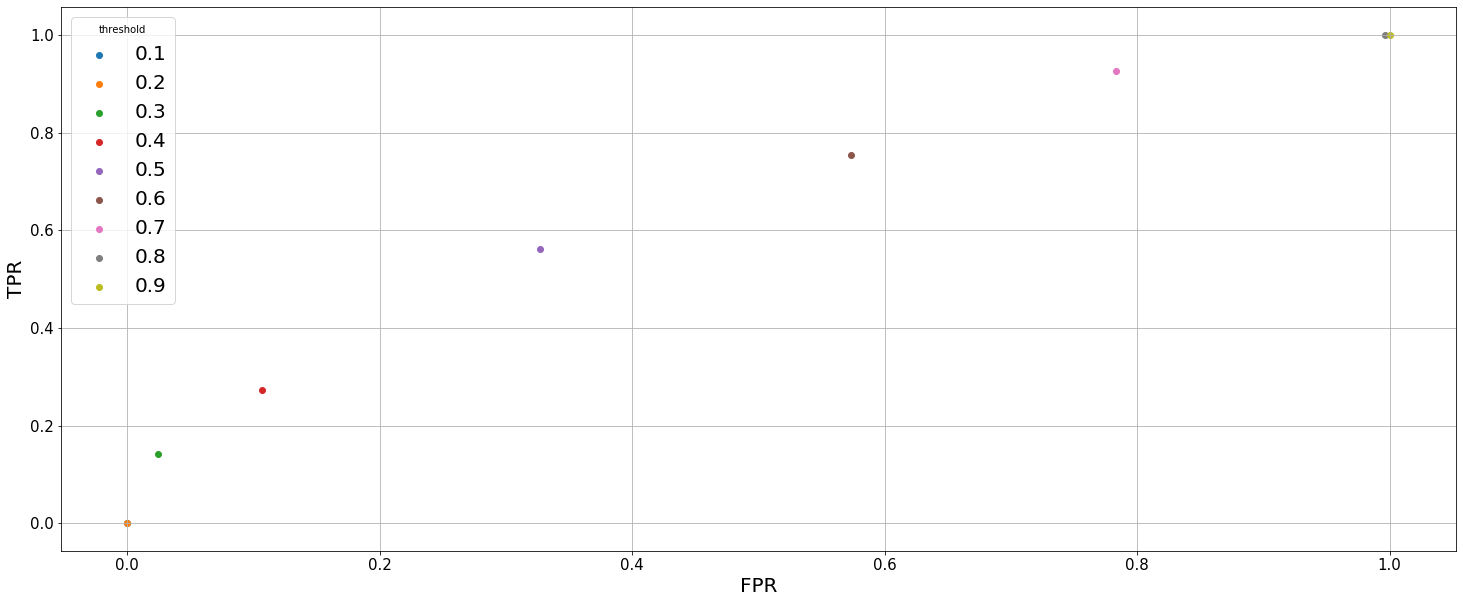

In [14]:
# ROC graph

x_categorical, x_continuous, y = prepare_data(1)
x_categorical = x_categorical[0]
x_continuous = x_continuous[0]
y = y[0]

tpr_list = []
fpr_list = []
thresholds = [i / 10 for i in range(1,10)]

for threshold in thresholds:
    tp, tn, fp, fn = evaluateFinalModel(models, x_categorical, x_continuous, y, threshold)

    # true positive rate. Number of true positives divided by total number of positives
    tpr = tp / (tp + fn) 
    # false positive rate. Number of false positives divided by total number of negatives.
    fpr = fp / (fp + tn)
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)

    
fig, ax = plt.subplots(figsize = (25, 10))
for i in range(len(thresholds)):
    ax.scatter(fpr_list[i], tpr_list[i], label = thresholds[i])
    
ax.legend(title = 'threshold', fontsize = 20)

ax.set_xlabel('FPR', fontsize = 20)
ax.set_ylabel('TPR', fontsize = 20)

ax.tick_params(labelsize = 15)

ax.grid(True)
plt.show()

In [15]:
auc = np.trapz(y = tpr_list, x = fpr_list)
print('AUC: ', auc)

AUC:  0.6582355347523176


C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


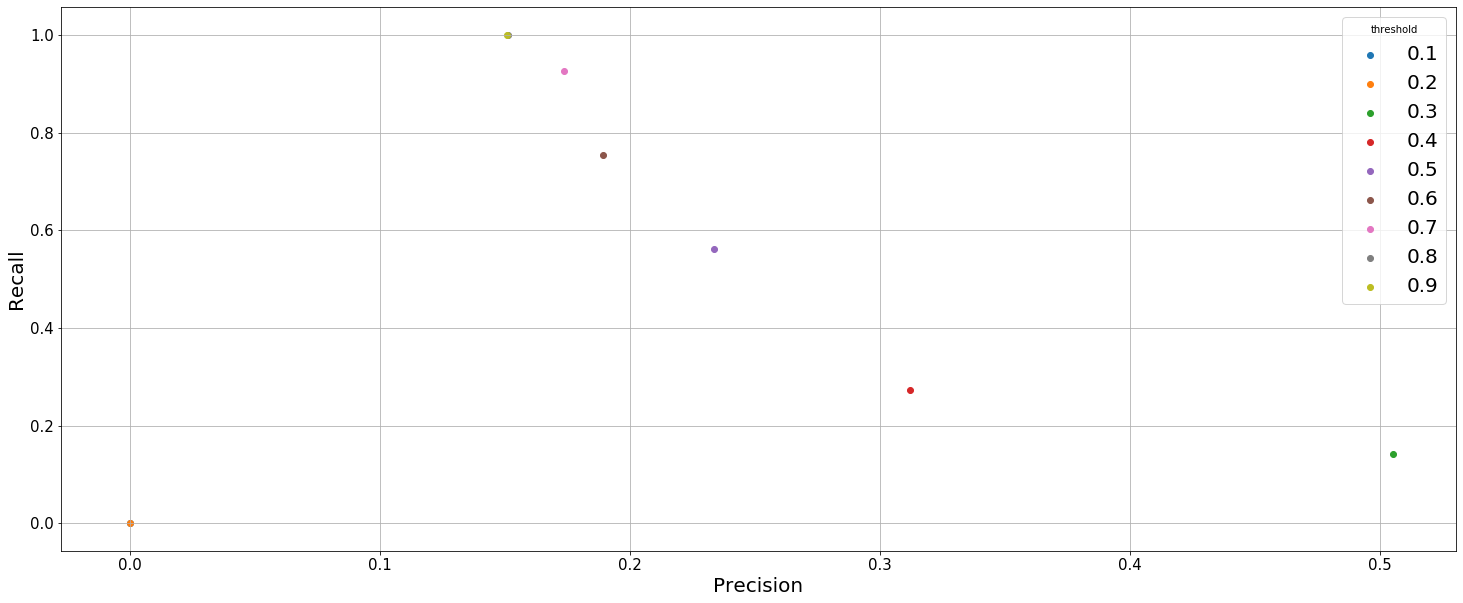

In [16]:
# precision vs recall

x_categorical, x_continuous, y = prepare_data(1)
x_categorical = x_categorical[0]
x_continuous = x_continuous[0]
y = y[0]

recall_list = []
prec_list = []
thresholds = [i / 10 for i in range(1,10)]

for threshold in thresholds:
    tp, tn, fp, fn = evaluateFinalModel(models, x_categorical, x_continuous, y, threshold)

    # recall
    recall = tp / (tp + fn) 
    
    # precision
    try:
        precision = tp / (tp + fp)
    except:
        precision = 0
    
    recall_list.append(recall)
    prec_list.append(precision)

    
fig, ax = plt.subplots(figsize = (25, 10))
for i in range(len(thresholds)):
    ax.scatter(prec_list[i], recall_list[i], label = thresholds[i])
    
ax.legend(title = 'threshold', fontsize = 20)

ax.set_xlabel('Precision', fontsize = 20)
ax.set_ylabel('Recall', fontsize = 20)

ax.tick_params(labelsize = 15)

ax.grid(True)
plt.show()

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


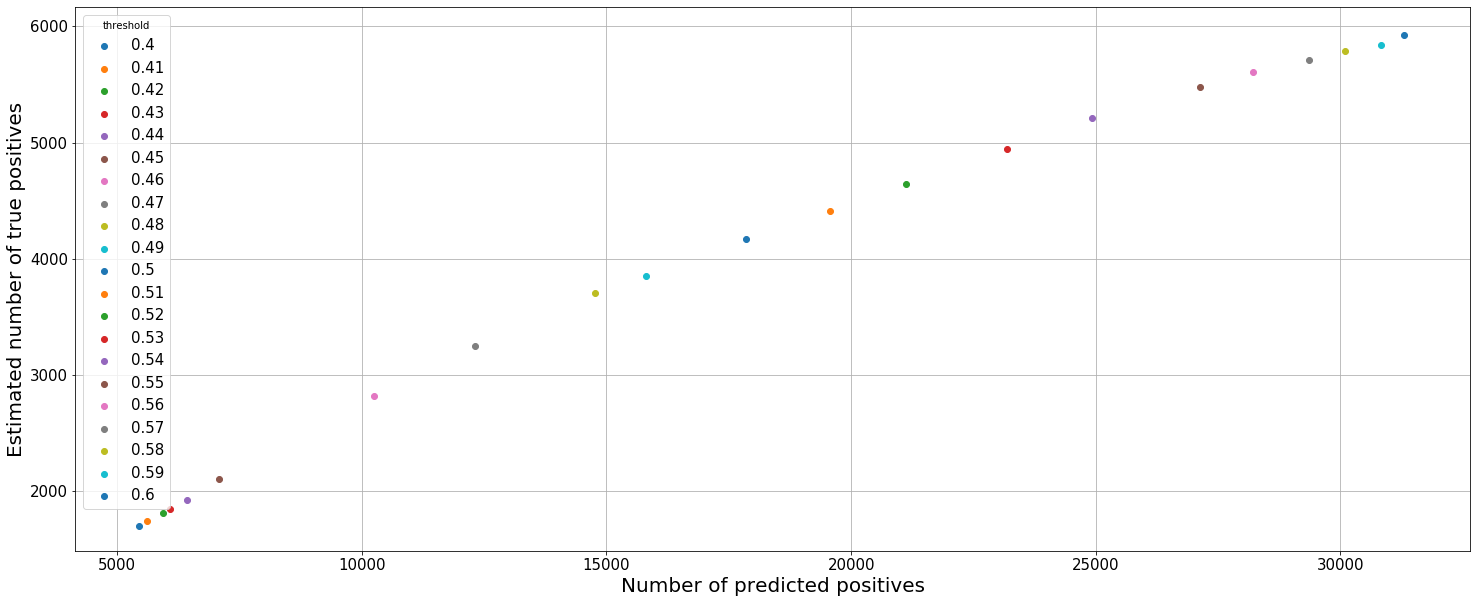

In [72]:
# calculate precisions for different thresholds

thresholds = np.arange(0.4, 0.61, 0.01)
precision_list = []

x_categorical, x_continuous, y = prepare_data(1)
x_categorical = x_categorical[0]
x_continuous = x_continuous[0]
y = y[0]

for threshold in thresholds:
    tp, tn, fp, fn = evaluateFinalModel(models, x_categorical, x_continuous, y, threshold)
    
    # precision
    try:
        precision = tp / (tp + fp)
    except:
        precision = 0
    
    precision_list.append(precision)


# calculate number of predicted positives of a whole dataset (for both campaign and control group)
# we will also calculate estimated number of true positives (= number of predicted positives * precision)

x_categorical_list, x_continuous_list, y_list = prepare_data(1, campaign_flag = False)
x_categorical = x_categorical_list[0]
x_continuous = x_continuous_list[0]
y = y_list[0]

# pp_list is a list with number of predicted positives for different thresholds
pp_list = []

# tp_list is a list with estimated numbers of true positives for different thresholds. 
# estimated number of true positives = number of predicted positives * precision
tp_list = []

for i, threshold in enumerate(thresholds):
    tp, tn, fp, fn = evaluateFinalModel(models, x_categorical, x_continuous, y, threshold)

    # pp indicates nuber of predicted positives 
    pp = tp + fp
    pp_list.append(pp)
    tp_list.append(pp * precision_list[i])

    
fig, ax = plt.subplots(figsize = (25, 10))
for i in range(len(thresholds)):
    ax.scatter(pp_list[i], tp_list[i], label = round(thresholds[i], 2))
    
ax.legend(title = 'threshold', fontsize = 15)

ax.set_xlabel('Number of predicted positives', fontsize = 20)
ax.set_ylabel('Estimated number of true positives', fontsize = 20)

ax.tick_params(labelsize = 15)

ax.grid(True)
plt.show()

## evaluating lift

In [22]:
x_categorical_list, x_continuous_list, y_list = prepare_data(1, campaign_flag = False)
x_categorical = x_categorical_list[0]
x_continuous = x_continuous_list[0]
y = y_list[0]

C:\Users\mbulk\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [23]:
x_categorical.shape

(41188, 39)

In [66]:
pred = finalModel(models, x_categorical, x_continuous)
threshold = 0.5
pred = np.array([0 if p[0] > threshold else 1 for p in pred])

In [67]:
len(pred[pred == 1])

17844

So our model says that there is almost 18000 clients for who our campaign will be successful but we know that our model has 25% of precision. So if we contact those 18000 clients we should have 25% accuracy.